In [21]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook')

In [22]:
ACQ_SWEEP_DIR = '../examples/comparisons/closed_boundary_DIIID/acq_sweep'
EI_DIR        = '../examples/comparisons/closed_boundary_DIIID/convergence_w25'
EI_RUN        = 'run_01'  # which run to use for EI

rows = []

# --- non-EI acq functions ---
for acq_folder in sorted(os.listdir(ACQ_SWEEP_DIR)):
    m_acq = re.match(r'acq:(.+)', acq_folder)
    if not m_acq:
        continue
    acq_func = m_acq.group(1)
    acq_dir = os.path.join(ACQ_SWEEP_DIR, acq_folder)

    for config in sorted(os.listdir(acq_dir)):
        m = re.match(r'lambda:([^,]+),coils:(\d+)', config)
        if not m:
            continue
        lam, coils = float(m.group(1)), int(m.group(2))
        config_dir = os.path.join(acq_dir, config)

        for run_dir in sorted(os.listdir(config_dir)):
            rpath = os.path.join(config_dir, run_dir, 'results.json')
            if not os.path.isfile(rpath):
                continue
            run_m = re.match(r'run_(\d+)', run_dir)
            run_idx = int(run_m.group(1)) if run_m else 0

            with open(rpath) as f:
                data = json.load(f)

            bayes = data['methods'].get('Bayesian', {})
            if not bayes:
                continue

            ref_costs = bayes.get('refinement_costs', [])
            ref_evals = bayes.get('refinement_evals', [])
            ref_times = bayes.get('refinement_times', [])
            n_bo      = int(bayes.get('n_bayesian_evals', 0))

            rows.append({
                'acq_func':            acq_func,
                'lambda':              lam,
                'coils':               coils,
                'run':                 run_idx,
                'best_cost':           bayes.get('best_cost', float('nan')),
                'n_evals':             int(bayes.get('n_evals', 0)),
                'n_bayesian_evals':    n_bo,
                'n_initial':           int(bayes.get('n_initial', 0)),
                'pts_refined':         int(bayes.get('pts_refined', 0)),
                'ref_costs_list':      ref_costs,
                'ref_evals_list':      ref_evals,
                'ref_times_list':      ref_times,
                'time':                float(bayes.get('time', 0)),
                'phase1_time':         float(bayes.get('time_bayesian_phase', 0)),
                'bayesian_stopping':   bayes.get('bayesian_stopping'),
                'refinement_stopping': bayes.get('refinement_stopping'),
            })

# --- EI and L-BFGS (one run per config from convergence_w25) ---
for config in sorted(os.listdir(EI_DIR)):
    m = re.match(r'lambda:([^,]+),coils:(\d+)', config)
    if not m:
        continue
    lam, coils = float(m.group(1)), int(m.group(2))
    rpath = os.path.join(EI_DIR, config, EI_RUN, 'results.json')
    if not os.path.isfile(rpath):
        continue

    with open(rpath) as f:
        data = json.load(f)

    # EI (Bayesian)
    bayes = data['methods'].get('Bayesian', {})
    if bayes:
        ref_costs = bayes.get('refinement_costs', [])
        ref_evals = bayes.get('refinement_evals', [])
        ref_times = bayes.get('refinement_times', [])
        n_bo      = int(bayes.get('n_bayesian_evals', 0))
        rows.append({
            'acq_func':            'EI',
            'lambda':              lam,
            'coils':               coils,
            'run':                 1,
            'best_cost':           bayes.get('best_cost', float('nan')),
            'n_evals':             int(bayes.get('n_evals', 0)),
            'n_bayesian_evals':    n_bo,
            'n_initial':           int(bayes.get('n_initial', 0)),
            'pts_refined':         int(bayes.get('pts_refined', 0)),
            'ref_costs_list':      ref_costs,
            'ref_evals_list':      ref_evals,
            'ref_times_list':      ref_times,
            'time':                float(bayes.get('time', 0)),
            'phase1_time':         float(bayes.get('time_bayesian_phase', 0)),
            'bayesian_stopping':   bayes.get('bayesian_stopping'),
            'refinement_stopping': bayes.get('refinement_stopping'),
        })

    # L-BFGS (stored directly, no refinement phases)
    lbfgs = data['methods'].get('Multi-start L-BFGS', {})
    if lbfgs:
        cost = lbfgs.get('best_cost', float('nan'))
        rows.append({
            'acq_func':            'L-BFGS',
            'lambda':              lam,
            'coils':               coils,
            'run':                 1,
            'best_cost':           cost,
            'n_evals':             int(lbfgs.get('n_evals', 0)),
            'n_bayesian_evals':    int(lbfgs.get('n_evals', 0)),
            'n_initial':           0,
            'pts_refined':         0,
            'ref_costs_list':      [],
            'ref_evals_list':      [],
            'ref_times_list':      [],
            'time':                float(lbfgs.get('time', 0)),
            'phase1_time':         float(lbfgs.get('time', 0)),
            'bayesian_stopping':   None,
            'refinement_stopping': None,
        })

df = pd.DataFrame(rows)
print(f'Loaded {len(df)} rows')
print(df.groupby(['acq_func', 'coils', 'lambda']).size().reset_index(name='n_runs').to_string())

Loaded 34 rows
   acq_func  coils        lambda  n_runs
0        EI      2  1.000000e-08       1
1        EI      2  1.000000e-07       1
2        EI      2  1.000000e-06       1
3        EI      2  1.000000e-05       1
4        EI      3  1.000000e-08       1
5        EI      3  1.000000e-07       1
6        EI      3  1.000000e-06       1
7        EI      3  1.000000e-05       1
8        EI      4  1.000000e-08       1
9    L-BFGS      2  1.000000e-08       1
10   L-BFGS      2  1.000000e-07       1
11   L-BFGS      2  1.000000e-06       1
12   L-BFGS      2  1.000000e-05       1
13   L-BFGS      3  1.000000e-08       1
14   L-BFGS      3  1.000000e-07       1
15   L-BFGS      3  1.000000e-06       1
16   L-BFGS      3  1.000000e-05       1
17   L-BFGS      4  1.000000e-08       1
18       PI      2  1.000000e-08       1
19       PI      2  1.000000e-07       1
20       PI      2  1.000000e-06       1
21       PI      2  1.000000e-05       1
22       PI      3  1.000000e-08       1
2

In [23]:
K = 5  # number of refinement points to use

def _kr(row):
    # L-BFGS has no refinement — use its metrics directly
    if row['acq_func'] == 'L-BFGS':
        return pd.Series({
            'Kr_cost':  row['best_cost'],
            'Kr_evals': row['n_evals'],
            'Kr_time':  row['time'],
        })
    costs = row['ref_costs_list']
    evals = row['ref_evals_list']
    times = row['ref_times_list']
    if len(costs) >= K and len(evals) >= K:
        return pd.Series({
            'Kr_cost':  float(costs[K-1]),
            'Kr_evals': row['n_bayesian_evals'] + int(sum(evals[:K])),
            'Kr_time':  row['phase1_time'] + (float(sum(times[:K])) if len(times) >= K else float('nan')),
        })
    return pd.Series({'Kr_cost': float('nan'), 'Kr_evals': float('nan'), 'Kr_time': float('nan')})

kr = df.apply(_kr, axis=1)
df['Kr_cost']  = kr['Kr_cost']
df['Kr_evals'] = kr['Kr_evals']
df['Kr_time']  = kr['Kr_time']
print(f"{df['Kr_cost'].notna().sum()} / {len(df)} rows have Kr metrics")

34 / 34 rows have Kr metrics


In [24]:
# Best cost heatmap per acq function (Kr_cost)
acq_funcs = sorted(df['acq_func'].unique())
valid = df.dropna(subset=['Kr_cost'])

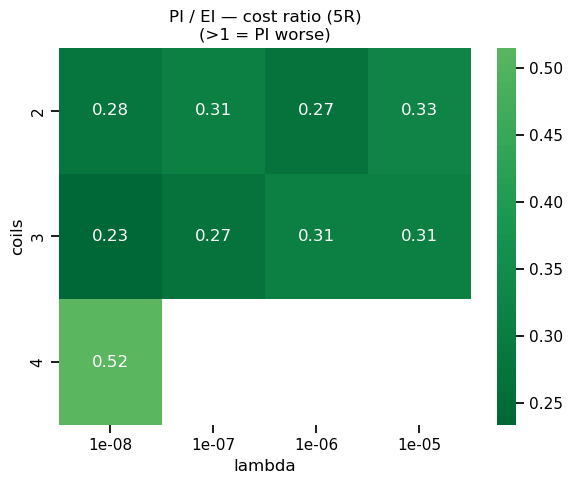

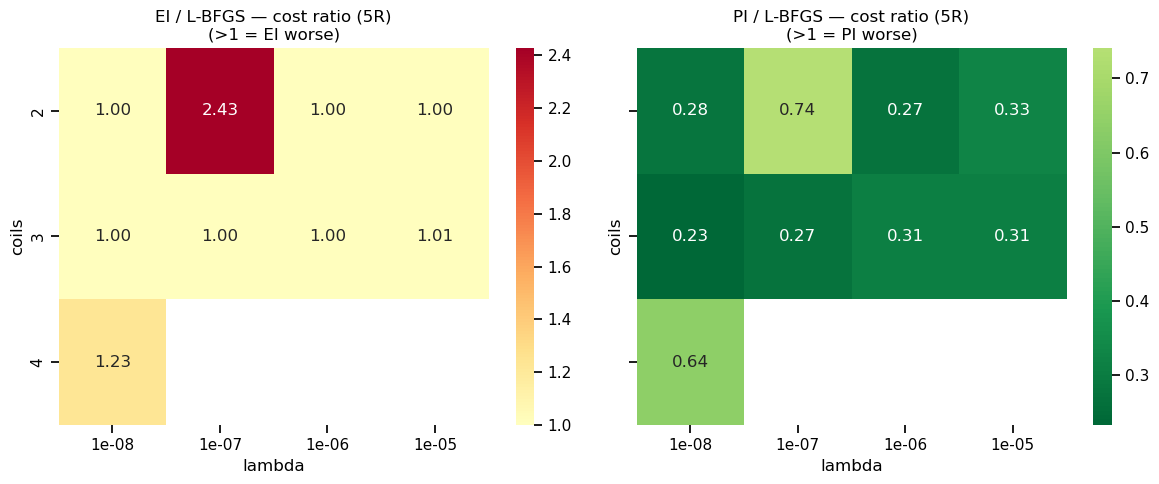

In [25]:
# Cost ratio heatmaps — each Bayesian acq vs EI, and each acq vs L-BFGS
valid = df.dropna(subset=['Kr_cost'])

ei_costs    = valid[valid['acq_func'] == 'EI'].set_index(['lambda', 'coils'])['Kr_cost']
lbfgs_costs = valid[valid['acq_func'] == 'L-BFGS'].set_index(['lambda', 'coils'])['Kr_cost']

bayesian_acqs = sorted(valid[~valid['acq_func'].isin(['L-BFGS'])]['acq_func'].unique())

for baseline_label, baseline_costs in [('EI', ei_costs), ('L-BFGS', lbfgs_costs)]:
    subjects = [a for a in bayesian_acqs if a != baseline_label]
    if not subjects:
        continue
    fig, axes = plt.subplots(1, len(subjects), figsize=(6 * len(subjects), 5), sharey=True)
    if len(subjects) == 1:
        axes = [axes]
    for ax, acq in zip(axes, subjects):
        sub = valid[valid['acq_func'] == acq].copy()
        sub = sub.join(baseline_costs.rename('baseline'), on=['lambda', 'coils'])
        sub['ratio'] = sub['Kr_cost'] / sub['baseline']
        pivot = sub.pivot_table(index='coils', columns='lambda', values='ratio')
        pivot = pivot.reindex(sorted(pivot.columns), axis=1)
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax, center=1.0)
        ax.set_title(f'{acq} / {baseline_label} — cost ratio ({K}R)\n(>1 = {acq} worse)')
        ax.set_xlabel('lambda')
        ax.set_ylabel('coils')
    plt.tight_layout()
    plt.show()

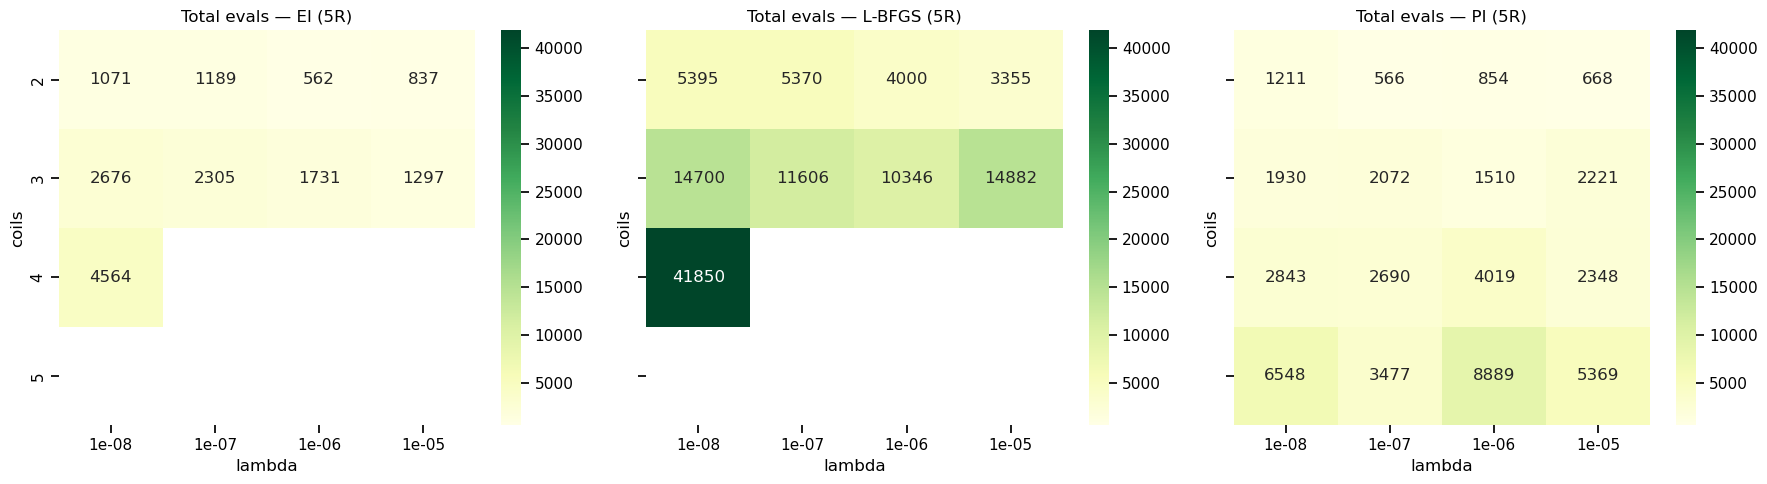

In [26]:
# Eval count heatmap per acq function (Kr_evals)
fig, axes = plt.subplots(1, len(acq_funcs), figsize=(6 * len(acq_funcs), 5), sharey=True)
if len(acq_funcs) == 1:
    axes = [axes]

all_evals = valid['Kr_evals']
vmin_e, vmax_e = all_evals.min(), all_evals.max()

for ax, acq in zip(axes, acq_funcs):
    sub = valid[valid['acq_func'] == acq]
    pivot = sub.pivot_table(index='coils', columns='lambda', values='Kr_evals')
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGn', ax=ax, vmin=vmin_e, vmax=vmax_e)
    ax.set_title(f'Total evals — {acq} ({K}R)')
    ax.set_xlabel('lambda')
    ax.set_ylabel('coils')

plt.tight_layout()
plt.show()

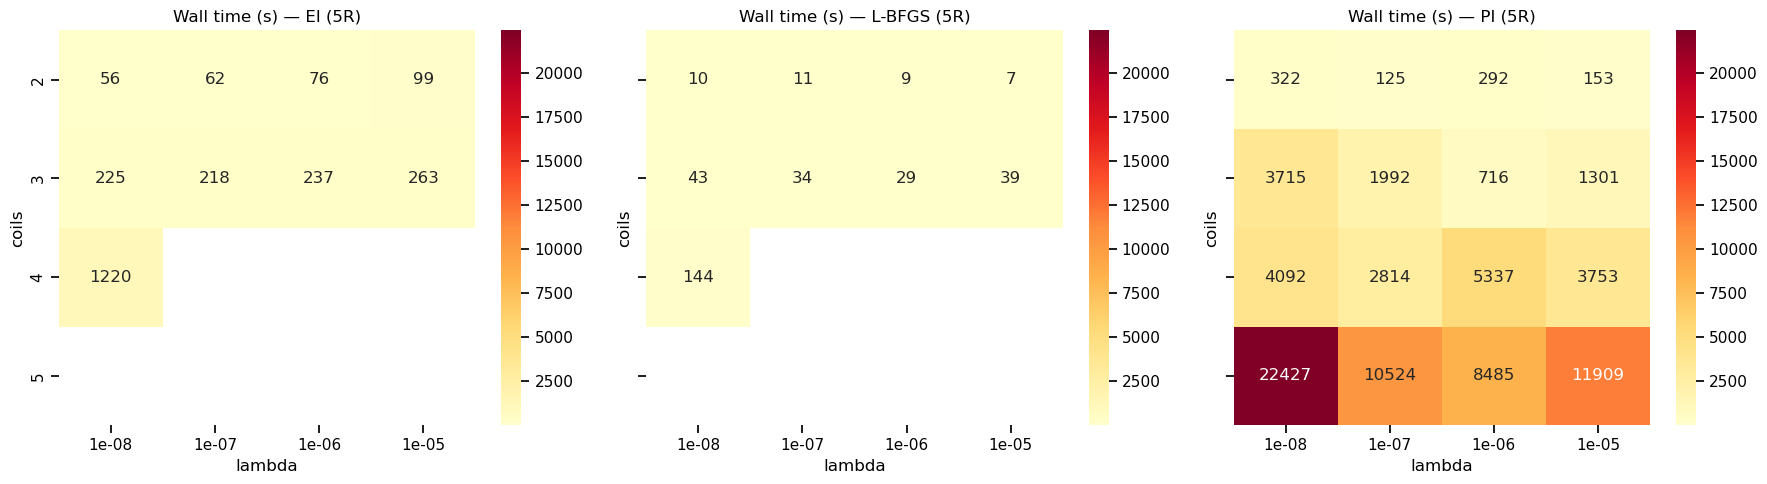

In [27]:
# Wall time heatmap per acq function (Kr_time)
fig, axes = plt.subplots(1, len(acq_funcs), figsize=(6 * len(acq_funcs), 5), sharey=True)
if len(acq_funcs) == 1:
    axes = [axes]

all_times = valid['Kr_time'].dropna()
vmin_t, vmax_t = all_times.min(), all_times.max()

for ax, acq in zip(axes, acq_funcs):
    sub = valid[valid['acq_func'] == acq]
    pivot = sub.pivot_table(index='coils', columns='lambda', values='Kr_time')
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, vmin=vmin_t, vmax=vmax_t)
    ax.set_title(f'Wall time (s) — {acq} ({K}R)')
    ax.set_xlabel('lambda')
    ax.set_ylabel('coils')

plt.tight_layout()
plt.show()

In [28]:
# Stopping criteria breakdown
stopping = df.groupby(['acq_func', 'bayesian_stopping']).size().reset_index(name='count')
print(stopping.to_string(index=False))

acq_func   bayesian_stopping  count
      EI bayesian_stagnation      9
      PI bayesian_stagnation     16
